# Detecting chromosomal aneuploidy in embryo biopsies from SNP-array data

**Rozhin Dabbaghi** | code sample for the VUB / UZ Brussel doctoral grant in Medical Genetics

**Aim.** Build a small, transparent pipeline that takes SNP-array readouts from an embryo biopsy
(B-allele frequency and LogR) together with the genotypes of both parents, and calls whole-chromosome
gains and losses, including the parent of origin and, for maternal trisomies, whether both maternal
homologs are present (BPH, typical of a meiosis I error) or two copies of a single homolog (SPH).

**Data.** All data here are *simulated*. I simulated them so that the true answer is known for every
chromosome, which lets me measure how well each step works. The idea of reading the B-allele frequency
separately for SNP categories defined by the parental genotypes comes from Verdyck et al. (2025),
*Genes* 16:115 (APCAD Part 2). This notebook is my own simplified version of that idea, not a
reimplementation of APCAD.

**Outline**
1. Simulate parents and embryos with known chromosome states
2. Add measurement noise typical of whole-genome-amplified DNA from a few cells
3. Group SNPs by parental genotype and look at one embryo
4. Choose the LogR cutoff with ROC analysis (Youden index)
5. Call every chromosome and evaluate the calls against the truth
6. Check how performance falls as the biopsy gets noisier
7. Limitations and what I would do next

In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)   # fixed seed so every run gives the same result
pd.set_option("display.width", 120)

# Approximate autosome lengths in Mb (GRCh38), used only to scale how many SNPs each chromosome gets
CHR_LEN = {1: 248, 2: 242, 3: 198, 4: 190, 5: 181, 6: 171, 7: 159, 8: 145, 9: 138, 10: 134, 11: 135,
           12: 133, 13: 114, 14: 107, 15: 102, 16: 90, 17: 83, 18: 80, 19: 59, 20: 64, 21: 47, 22: 51}
CHROMS = list(CHR_LEN)
SNPS_PER_MB = 10                      # about 29,000 SNPs in total, far fewer than a real array but enough
GT = {0: "AA", 1: "AB", 2: "BB"}      # genotype = number of B alleles

## 1. Simulating parents and embryos

Each parent carries two haplotypes per chromosome. An embryo normally receives one recombinant
chromatid from each parent (I model one crossover per chromosome). For an abnormal chromosome I change
which copies the embryo receives:

| state | copies in the embryo | what it represents |
|---|---|---|
| `normal` | 1 maternal + 1 paternal | disomy |
| `mat_trisomy_BPH` | both maternal homologs + 1 paternal | meiosis I non-disjunction |
| `mat_trisomy_SPH` | 2 identical maternal copies + 1 paternal | meiosis II-type error |
| `mat_monosomy` | paternal copy only | loss of the maternal chromosome |
| `pat_monosomy` | maternal copy only | loss of the paternal chromosome |

Maternal errors get most of the weight, and chromosomes 15, 16, 21 and 22 are picked more often,
because that is the pattern seen in human embryos, especially with advanced maternal age.

In [3]:
def simulate_parents(rng):
    """Two haplotypes per parent at every SNP (0 = A allele, 1 = B allele)."""
    parts = []
    for c in CHROMS:
        n = CHR_LEN[c] * SNPS_PER_MB
        pos = np.sort(rng.uniform(0, CHR_LEN[c], n))
        p_b = rng.uniform(0.05, 0.95, n)                  # population frequency of the B allele
        mat = (rng.random((n, 2)) < p_b[:, None]).astype(int)
        pat = (rng.random((n, 2)) < p_b[:, None]).astype(int)
        parts.append(pd.DataFrame({"chrom": c, "pos_mb": pos,
                                   "mat_h1": mat[:, 0], "mat_h2": mat[:, 1],
                                   "pat_h1": pat[:, 0], "pat_h2": pat[:, 1]}))
    df = pd.concat(parts, ignore_index=True)
    df["mat_gt"] = df.mat_h1 + df.mat_h2
    df["pat_gt"] = df.pat_h1 + df.pat_h2
    # SNP category = maternal genotype x paternal genotype, e.g. "AAxBB"
    df["cat"] = df.mat_gt.map(GT) + "x" + df.pat_gt.map(GT)
    return df


def transmit(h1, h2, pos, rng):
    """One recombinant chromatid: one parental haplotype up to a random crossover, the other after it."""
    crossover = rng.uniform(pos.min(), pos.max())
    first, second = (h1, h2) if rng.random() < 0.5 else (h2, h1)
    return np.where(pos < crossover, first, second)


STATES = ["mat_trisomy_BPH", "mat_trisomy_SPH", "mat_monosomy", "pat_monosomy"]
STATE_P = [0.45, 0.20, 0.25, 0.10]
CHROM_W = np.array([3.0 if c in (15, 16, 21, 22) else 1.0 for c in CHROMS])
CHROM_W /= CHROM_W.sum()


def random_karyotype(rng, p_euploid=0.45):
    """Return {chromosome: state} for the abnormal chromosomes of one embryo (empty dict = euploid)."""
    if rng.random() < p_euploid:
        return {}
    n_abn = rng.choice([1, 2, 3], p=[0.6, 0.3, 0.1])
    chroms = rng.choice(CHROMS, size=n_abn, replace=False, p=CHROM_W)
    return {int(c): str(rng.choice(STATES, p=STATE_P)) for c in chroms}


def make_embryo(par, karyotype, rng):
    """True B-allele fraction and copy number at every SNP for one embryo."""
    true_baf = np.zeros(len(par))
    cn = np.zeros(len(par))
    for c, idx in par.groupby("chrom").indices.items():
        d = par.iloc[idx]
        pos = d.pos_mb.values
        mh1, mh2, ph1, ph2 = d.mat_h1.values, d.mat_h2.values, d.pat_h1.values, d.pat_h2.values
        m = transmit(mh1, mh2, pos, rng)
        p = transmit(ph1, ph2, pos, rng)
        state = karyotype.get(c, "normal")
        copies = {"normal":          [m, p],
                  "mat_trisomy_BPH": [mh1, mh2, p],
                  "mat_trisomy_SPH": [m, m, p],
                  "mat_monosomy":    [p],
                  "pat_monosomy":    [m]}[state]
        true_baf[idx] = np.sum(copies, axis=0) / len(copies)
        cn[idx] = len(copies)
    return true_baf, cn

## 2. Measurement noise

A trophectoderm biopsy gives a few cells, so the DNA is whole-genome amplified before it goes on the array.
I model three sources of error:
* random noise on every BAF and LogR value,
* allele drop-out, where a heterozygous SNP reads as homozygous because one allele failed to amplify,
* a chromosome-wide LogR shift, standing in for uneven amplification. This is the error that makes
  LogR alone unreliable, because it moves a whole chromosome at once and does not average out.

LogR on SNP arrays is compressed, so a true log2 ratio is multiplied by about 0.55.

In [4]:
def measure(true_baf, cn, chrom, rng, baf_sd=0.05, logr_sd=0.25, chrom_shift_sd=0.08, dropout=0.03):
    n = len(cn)
    baf = true_baf + rng.normal(0, baf_sd, n)
    het = (true_baf > 0) & (true_baf < 1)
    drop = het & (rng.random(n) < dropout)
    baf[drop] = rng.integers(0, 2, drop.sum()) + rng.normal(0, baf_sd, drop.sum())
    baf = np.clip(baf, 0, 1)

    shift = {c: rng.normal(0, chrom_shift_sd) for c in CHROMS}
    logr = 0.55 * np.log2(cn / 2) + np.vectorize(shift.get)(chrom) + rng.normal(0, logr_sd, n)
    return baf, logr


def simulate_embryo(rng, karyotype=None, **noise):
    par = simulate_parents(rng)
    if karyotype is None:
        karyotype = random_karyotype(rng)
    true_baf, cn = make_embryo(par, karyotype, rng)
    par["baf"], par["logr"] = measure(true_baf, cn, par.chrom.values, rng, **noise)
    return par, karyotype

## 3. Reading the B-allele frequency by SNP category

The raw BAF of all SNPs mixes many situations, so on its own it is hard to read. Splitting SNPs by
parental genotype makes the expected embryo BAF a known number for every chromosome state:

**Mother and father homozygous for opposite alleles (`AAxBB`, `BBxAA`).** The embryo gets exactly
one allele type from each parent, so I can measure the *paternal share* of the signal
(BAF for `AAxBB`, 1 - BAF for `BBxAA`):

| state | paternal share |
|---|---|
| normal | 0.5 |
| maternal trisomy | 1/3 |
| maternal monosomy | 1 |
| paternal monosomy | 0 |

**Mother heterozygous, father homozygous (`ABxAA`, `ABxBB`).** Here I fold the BAF so the paternal
allele is always counted as A. A normal chromosome sits at 0 or 0.5 depending on which maternal allele
was passed on. If both maternal homologs are present (BPH), *every* SNP sits at 1/3. If two copies of the
same maternal homolog are present (SPH), SNPs sit at 0 or 2/3. So the fraction of these SNPs close to
1/3 separates BPH from SPH without needing to phase the parental haplotypes.

Below is one embryo I set up by hand, with a BPH trisomy 16, an SPH trisomy 21 and a maternal monosomy 22.

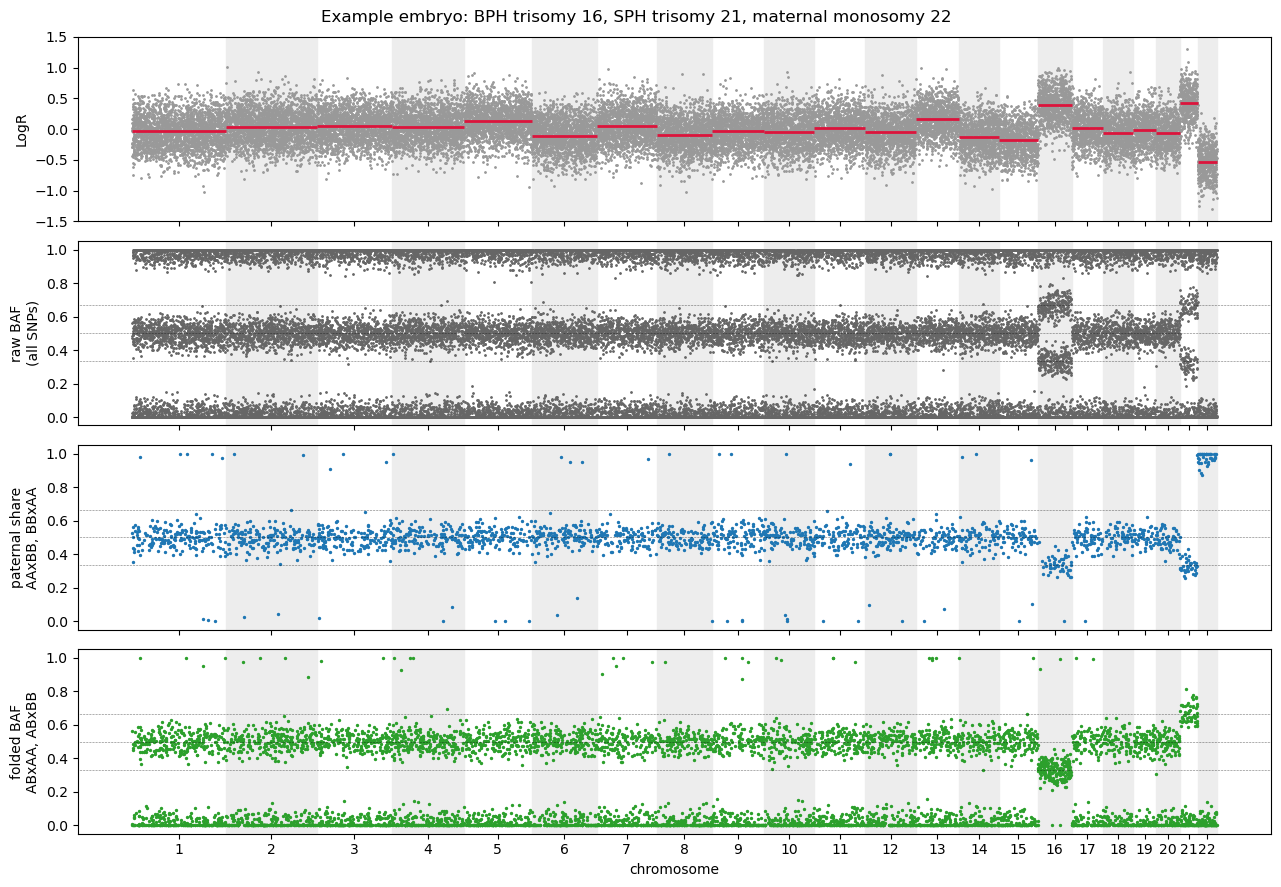

In [5]:
example, example_k = simulate_embryo(rng, karyotype={16: "mat_trisomy_BPH", 21: "mat_trisomy_SPH",
                                                     22: "mat_monosomy"})


def paternal_share(d):
    inf = d[d.cat.isin(["AAxBB", "BBxAA"])]
    return np.where(inf.cat == "AAxBB", inf.baf, 1 - inf.baf), inf


def folded_mat_het(d):
    mh = d[d.cat.isin(["ABxAA", "ABxBB"])]
    return np.where(mh.cat == "ABxAA", mh.baf, 1 - mh.baf), mh


def genome_x(d):
    """Continuous x coordinate so the chromosomes sit side by side on one plot."""
    offset = np.cumsum([0] + [CHR_LEN[c] for c in CHROMS[:-1]])
    off = dict(zip(CHROMS, offset))
    return d.pos_mb + d.chrom.map(off), off


def plot_embryo(d, title):
    x, off = genome_x(d)
    ps, inf = paternal_share(d)
    fm, mh = folded_mat_het(d)
    fig, ax = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
    ax[0].scatter(x, d.logr, s=1, c="0.6", rasterized=True)
    for c in CHROMS:
        s = d.chrom == c
        ax[0].hlines(d.logr[s].median(), off[c], off[c] + CHR_LEN[c], color="crimson", lw=2)
    ax[0].set_ylim(-1.5, 1.5); ax[0].set_ylabel("LogR")
    ax[1].scatter(x, d.baf, s=1, c="0.4", rasterized=True); ax[1].set_ylabel("raw BAF\n(all SNPs)")
    ax[2].scatter(x[inf.index], ps, s=2, c="tab:blue", rasterized=True); ax[2].set_ylabel("paternal share\nAAxBB, BBxAA")
    ax[3].scatter(x[mh.index], fm, s=2, c="tab:green", rasterized=True); ax[3].set_ylabel("folded BAF\nABxAA, ABxBB")
    for a in ax[1:]:
        a.set_ylim(-0.05, 1.05)
        for y in (1 / 3, 0.5, 2 / 3):
            a.axhline(y, color="k", lw=0.4, ls=":")
    for a in ax:
        for i, c in enumerate(CHROMS):
            if i % 2:
                a.axvspan(off[c], off[c] + CHR_LEN[c], color="0.93", zorder=0)
    ax[3].set_xticks([off[c] + CHR_LEN[c] / 2 for c in CHROMS]); ax[3].set_xticklabels(CHROMS)
    ax[3].set_xlabel("chromosome")
    fig.suptitle(title); fig.tight_layout()
    return fig


plot_embryo(example, "Example embryo: BPH trisomy 16, SPH trisomy 21, maternal monosomy 22");
plt.show()

**What the plot shows.** In the LogR track, chromosomes 16 and 21 sit higher and 22 sits lower, but the
chromosome-wide noise makes some normal chromosomes drift too. The raw BAF of all SNPs is hard to read by
eye. The two category tracks are clearer: the paternal share drops to 1/3 on both trisomies (so the extra
copy is maternal) and rises to 1 on chromosome 22 (only paternal alleles left, so the maternal copy is
lost). In the folded track, chromosome 16 collapses onto a single band at 1/3 (both maternal homologs,
BPH), while chromosome 21 splits into 0 and 2/3 (one maternal homolog duplicated, SPH).

## 4. Summarising each chromosome and choosing the LogR cutoff

For every chromosome I compute three numbers:
* `logr_med`: median LogR,
* `pat_share`: median paternal share over `AAxBB`/`BBxAA` SNPs,
* `bph_frac`: fraction of `ABxAA`/`ABxBB` SNPs with folded BAF between 0.25 and 0.42 (close to 1/3).

I then simulate 300 embryos and ask a question I also asked in my MSc thesis with qPCR data: how well does a
single measurement (`logr_med`) separate two groups, and which cutoff gives the best balance of sensitivity
and specificity? I answer it with an ROC curve and the Youden index, written out in NumPy so every step is visible.

In [6]:
def summarise(d):
    rows = []
    for c, g in d.groupby("chrom"):
        ps, _ = paternal_share(g)
        fm, _ = folded_mat_het(g)
        rows.append({"chrom": c,
                     "logr_med": g.logr.median(),
                     "pat_share": np.median(ps),
                     "bph_frac": np.mean((fm > 0.25) & (fm < 0.42)),
                     "n_inf": len(ps), "n_mathet": len(fm)})
    return pd.DataFrame(rows)


def build_cohort(n_embryos, rng, **noise):
    tables = []
    for e in range(n_embryos):
        d, k = simulate_embryo(rng, **noise)
        s = summarise(d)
        s["embryo"] = e
        s["truth"] = s.chrom.map(lambda c: k.get(c, "normal"))
        tables.append(s)
    return pd.concat(tables, ignore_index=True)


train = build_cohort(300, rng)
print(train.truth.value_counts())
train.head()

truth
normal             6352
mat_trisomy_BPH     122
mat_monosomy         58
mat_trisomy_SPH      46
pat_monosomy         22
Name: count, dtype: int64


,chrom,logr_med,pat_share,bph_frac,n_inf,n_mathet,embryo,truth
0,1,0.004287,0.504857,0.023669,196,507,0,normal
1,2,0.028465,0.502437,0.023529,174,510,0,normal
2,3,0.005382,0.494160,0.026634,142,413,0,normal
3,4,0.034004,0.496301,0.040506,136,395,0,normal
4,5,-0.066813,0.510319,0.015464,137,388,0,normal


Gain: AUC 0.999, cutoff LogR > 0.177, sensitivity 98.8%, specificity 98.5%
Loss: AUC 1.000, cutoff LogR < -0.393, sensitivity 100.0%, specificity 100.0%


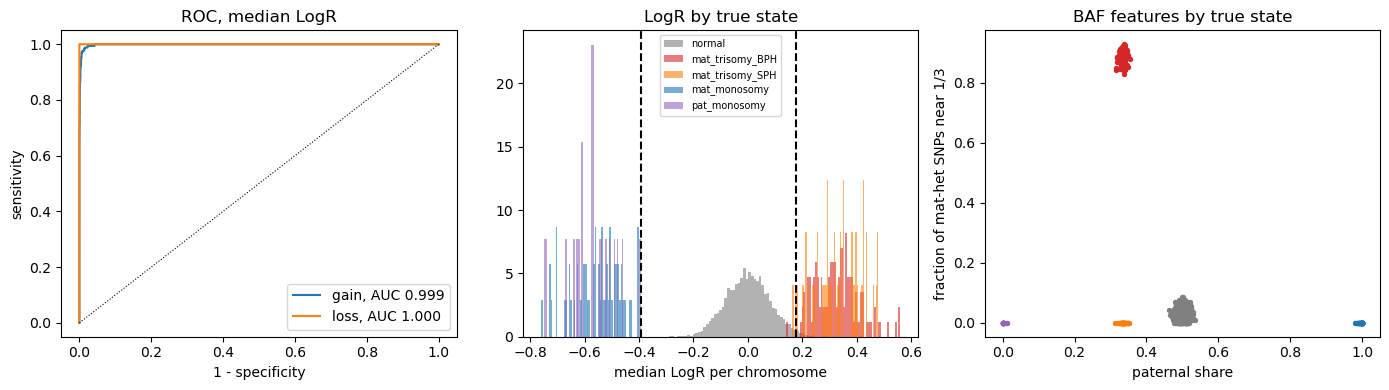

In [7]:
def roc_curve(scores, labels):
    """Sensitivity and 1 - specificity at every possible cutoff (label 1 = positive)."""
    order = np.argsort(-scores)
    s, y = scores[order], labels[order]
    tp = np.cumsum(y); fp = np.cumsum(1 - y)
    tpr = np.r_[0, tp / y.sum()]
    fpr = np.r_[0, fp / (1 - y).sum()]
    thresholds = np.r_[np.inf, s]
    auc = np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2)   # trapezoid rule
    return fpr, tpr, thresholds, auc


def youden_cutoff(fpr, tpr, thr):
    j = tpr - fpr
    i = np.argmax(j)
    return thr[i], tpr[i], 1 - fpr[i]


# Gains: trisomic vs disomic chromosomes, score = median LogR
gain_set = train[train.truth.isin(["normal", "mat_trisomy_BPH", "mat_trisomy_SPH"])]
yg = gain_set.truth.str.contains("trisomy").astype(int).values
fpr_g, tpr_g, thr_g, auc_g = roc_curve(gain_set.logr_med.values, yg)
GAIN_CUT, sens_g, spec_g = youden_cutoff(fpr_g, tpr_g, thr_g)

# Losses: monosomic vs disomic chromosomes, score = minus median LogR
loss_set = train[train.truth.isin(["normal", "mat_monosomy", "pat_monosomy"])]
yl = loss_set.truth.str.contains("monosomy").astype(int).values
fpr_l, tpr_l, thr_l, auc_l = roc_curve(-loss_set.logr_med.values, yl)
LOSS_CUT, sens_l, spec_l = youden_cutoff(fpr_l, tpr_l, thr_l)
LOSS_CUT = -LOSS_CUT

print(f"Gain: AUC {auc_g:.3f}, cutoff LogR > {GAIN_CUT:.3f}, sensitivity {sens_g:.1%}, specificity {spec_g:.1%}")
print(f"Loss: AUC {auc_l:.3f}, cutoff LogR < {LOSS_CUT:.3f}, sensitivity {sens_l:.1%}, specificity {spec_l:.1%}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(fpr_g, tpr_g, label=f"gain, AUC {auc_g:.3f}")
ax[0].plot(fpr_l, tpr_l, label=f"loss, AUC {auc_l:.3f}")
ax[0].plot([0, 1], [0, 1], "k:", lw=0.8)
ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity"); ax[0].set_title("ROC, median LogR"); ax[0].legend()
for t, col in [("normal", "0.5"), ("mat_trisomy_BPH", "tab:red"), ("mat_trisomy_SPH", "tab:orange"),
               ("mat_monosomy", "tab:blue"), ("pat_monosomy", "tab:purple")]:
    s = train[train.truth == t]
    ax[1].hist(s.logr_med, bins=60, alpha=0.6, color=col, label=t, density=True)
    ax[2].scatter(s.pat_share, s.bph_frac, s=8, color=col, label=t)
ax[1].axvline(GAIN_CUT, color="k", ls="--"); ax[1].axvline(LOSS_CUT, color="k", ls="--")
ax[1].set_xlabel("median LogR per chromosome"); ax[1].set_title("LogR by true state"); ax[1].legend(fontsize=7)
ax[2].set_xlabel("paternal share"); ax[2].set_ylabel("fraction of mat-het SNPs near 1/3")
ax[2].set_title("BAF features by true state")
fig.tight_layout(); plt.show()

LogR alone separates the groups well but not perfectly: the chromosome-wide shift pushes some normal
chromosomes over the cutoff and pulls some abnormal ones under it. The right-hand panel shows why the BAF
categories help. Every state lands in its own corner, because the paternal share and the fraction of SNPs
near 1/3 depend on *which* copies are present, not on how much DNA was amplified.

## 5. Calling each chromosome

The calling rule combines both sources of evidence. A copy-number call needs LogR past the cutoff **and** a
paternal share consistent with it, so a noisy LogR on its own cannot create a false call. The thresholds on
the paternal share sit halfway between the expected values (for example 0.42 lies between 1/3 and 1/2).
I also report a LogR-only caller to see what the BAF evidence adds.

In [8]:
def call(row, use_baf=True):
    gain = row.logr_med > GAIN_CUT
    loss = row.logr_med < LOSS_CUT
    if not use_baf:
        return "gain" if gain else "loss" if loss else "normal"
    if gain and row.pat_share < 0.42:
        return "mat_trisomy_BPH" if row.bph_frac > 0.5 else "mat_trisomy_SPH"
    if loss and row.pat_share > 0.75:
        return "mat_monosomy"
    if loss and row.pat_share < 0.25:
        return "pat_monosomy"
    return "normal"


test = build_cohort(300, rng)            # fresh embryos, not used to pick the cutoffs
test["call"] = test.apply(call, axis=1)
test["call_logr_only"] = test.apply(call, axis=1, use_baf=False)

# Chromosome-level calls: rows = truth, columns = call (short labels so the table fits the page)
SHORT = {"normal": "normal", "mat_trisomy_BPH": "trisomy BPH", "mat_trisomy_SPH": "trisomy SPH",
         "mat_monosomy": "mat. loss", "pat_monosomy": "pat. loss"}
pd.crosstab(test.truth.map(SHORT), test.call.map(SHORT))

call,mat. loss,normal,pat. loss,trisomy BPH,trisomy SPH
truth,,,,,
mat. loss,64,3,0,0,0
normal,0,6366,0,0,0
pat. loss,0,0,25,0,0
trisomy BPH,0,1,0,90,0
trisomy SPH,0,3,0,0,48


In [9]:
def embryo_level(t, col):
    """An embryo is called aneuploid if any chromosome is called abnormal."""
    e = t.groupby("embryo").agg(true_aneu=("truth", lambda s: (s != "normal").any()),
                                called_aneu=(col, lambda s: (s != "normal").any()))
    tp = (e.true_aneu & e.called_aneu).sum(); fn = (e.true_aneu & ~e.called_aneu).sum()
    tn = (~e.true_aneu & ~e.called_aneu).sum(); fp = (~e.true_aneu & e.called_aneu).sum()
    return {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
            "euploid embryos wrongly called aneuploid": int(fp), "aneuploid embryos missed": int(fn)}


summary = pd.DataFrame({"LogR only": embryo_level(test, "call_logr_only"),
                        "LogR + BAF categories": embryo_level(test, "call")}).T
exact = (test.call == test.truth).mean()
print(f"Exact chromosome state (incl. parent of origin and BPH/SPH) correct for {exact:.2%} of chromosomes\n")
summary

Exact chromosome state (incl. parent of origin and BPH/SPH) correct for 99.89% of chromosomes



,sensitivity,specificity,euploid embryos wrongly called aneuploid,aneuploid embryos missed
LogR only,0.993827,0.695652,42.0,1.0
LogR + BAF categories,0.987654,1.000000,0.0,2.0


The embryo-level numbers matter most clinically. A euploid embryo wrongly called aneuploid is a healthy embryo
that may be discarded; an aneuploid embryo that is missed may be transferred and lead to implantation failure
or miscarriage. Adding the BAF evidence mainly reduces the first kind of error, because a chromosome shifted
by amplification noise still shows a paternal share of 0.5.

This also shows something the ROC curve in section 4 hides. At the chromosome level, LogR alone reached an
AUC close to 1 and about 98.5% specificity. But every embryo has 22 autosomes, so even a 1.5% false-positive
rate per chromosome means roughly one in four euploid embryos gets at least one false call
(1 - 0.985^22 ≈ 0.28). A test that looks excellent per chromosome can still be poor per embryo, which is the
level at which the clinical decision is made.

## 6. How robust is this to biopsy quality?

Poorer biopsies mean more noise. I repeat the evaluation while increasing the chromosome-wide LogR shift
and the BAF noise together (keeping the cutoffs chosen in section 4).

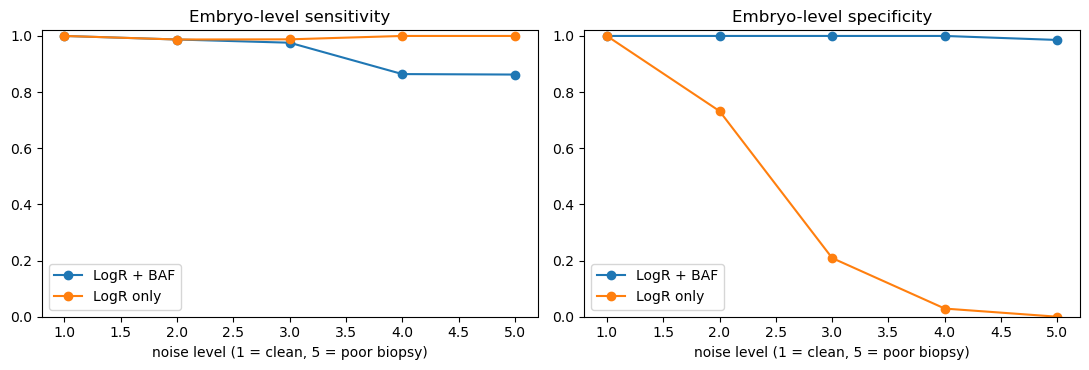

,noise level,method,sensitivity,specificity,euploid embryos wrongly called aneuploid,aneuploid embryos missed
0,1,LogR only,1.000,1.000,0,0
1,1,LogR + BAF,1.000,1.000,0,0
2,2,LogR only,0.987,0.732,19,1
3,2,LogR + BAF,0.987,1.000,0,1
4,3,LogR only,0.988,0.209,53,1
5,3,LogR + BAF,0.976,1.000,0,2
6,4,LogR only,1.000,0.029,67,0
7,4,LogR + BAF,0.864,1.000,0,11
8,5,LogR only,1.000,0.000,70,0
9,5,LogR + BAF,0.862,0.986,1,11


In [10]:
rows = []
for level, (shift_sd, baf_sd) in enumerate([(0.04, 0.03), (0.08, 0.05), (0.12, 0.08), (0.16, 0.11), (0.20, 0.14)]):
    t = build_cohort(150, rng, chrom_shift_sd=shift_sd, baf_sd=baf_sd)
    t["call"] = t.apply(call, axis=1)
    t["call_logr_only"] = t.apply(call, axis=1, use_baf=False)
    for name, col in [("LogR only", "call_logr_only"), ("LogR + BAF", "call")]:
        r = embryo_level(t, col)
        rows.append({"noise level": level + 1, "method": name, **r})
noise = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, g in noise.groupby("method"):
    ax[0].plot(g["noise level"], g.sensitivity, "o-", label=name)
    ax[1].plot(g["noise level"], g.specificity, "o-", label=name)
ax[0].set_title("Embryo-level sensitivity"); ax[1].set_title("Embryo-level specificity")
for a in ax:
    a.set_xlabel("noise level (1 = clean, 5 = poor biopsy)")
    a.set_ylim(0, 1.02)
    a.legend()
fig.tight_layout(); plt.show()
noise.round(3)

As noise increases, the LogR-only caller keeps finding the aneuploid embryos but calls almost every euploid
embryo abnormal as well, so it becomes useless. The combined caller keeps its specificity, but it starts to
miss abnormal chromosomes at the two noisiest levels, because the paternal share and LogR no longer both pass
their thresholds. For a clinical test that trade-off would need a decision: at some point it is better to
report a sample as "no result, re-biopsy" than to force a call. A next version could return that third
outcome when the two sources of evidence disagree.

## 7. Limitations and next steps

This is a deliberately simple model, and several things that matter in real embryos are left out:
* **Mosaicism.** Every cell here has the same karyotype. A mosaic biopsy gives intermediate LogR and BAF
  values, and calling it needs a continuous estimate of the abnormal cell fraction rather than fixed cutoffs.
* **Segmental changes.** I only call whole chromosomes. Segment-level calls would need a segmentation step
  (for example circular binary segmentation) before summarising.
* **Recombination in trisomies.** My BPH trisomies carry two non-recombinant maternal homologs. In reality,
  crossovers make parts of a meiosis I trisomy look like SPH, so `bph_frac` should be computed per segment.
* **Real noise structure.** Amplification bias follows GC content and fragment length and is correlated
  along the genome, not a single shift per chromosome.
* **Cutoffs** were tuned on simulated data. On real data they would be validated against a reference
  method (for example karyomapping, or re-biopsy of the embryo) on an independent set of samples.

Next I would like to run the same logic on real SNP-array or low-pass sequencing data from embryo
biopsies, add segmentation and a mosaicism estimate, and compare the calls with an established method.